SVM Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


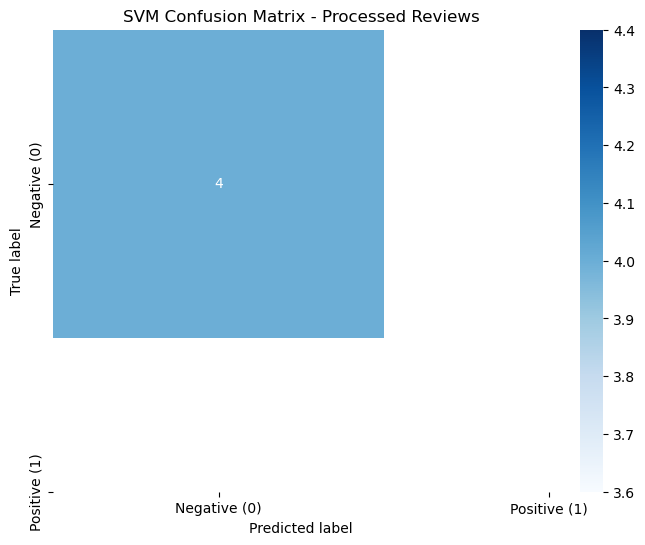

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


df = pd.read_csv('Processed_Reviews 2.csv')

df = df.dropna(subset=['lemmatized', 'label'])

#Pre-processing
X_text = df['lemmatized']
y = df['label'].astype(int) 

#Vectorization
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(X_text)

#Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

svm_clf = SVC(kernel='linear').fit(X_train, y_train)

#Evaluation
svm_predicted = svm_clf.predict(X_test)

print("SVM Classifier Report:")
print(classification_report(y_test, svm_predicted))

svm_cm = confusion_matrix(y_test, svm_predicted)

plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('SVM Confusion Matrix - Processed Reviews')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()